In [1]:
#1 imports + load datasets
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

data_path = "../data/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# NOTE: xarray open is optional now (netCDF4 does the real work fast).
# Keeping this only if you like inspecting ds.
ds = xr.open_dataset(data_path, engine="netcdf4")  # IMPORTANT: force engine
print(ds)


<xarray.Dataset> Size: 4GB
Dimensions:     (time: 167, station: 594107)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB ...
    longitude   (station) float64 5MB ...
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: (12/50)
    title:                           SBC LTER: Time series of quarterly NetCD...
    summary:                         Wet biomass (kg) of giant kelp (Macrocys...
    keywords:      

In [2]:
#2 imports + load datasets
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -119.0

lat = ds["latitude"].values
lon = ds["longitude"].values

mask_np = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
stations_all = np.flatnonzero(mask_np)

print("Stations in region:", stations_all.size)
print("Example station ids:", stations_all[:10])
print(ds)


Stations in region: 114834
Example station ids: [160882 161406 161433 163553 163554 163555 163556 163558 163559 163560]
<xarray.Dataset> Size: 4GB
Dimensions:     (time: 167, station: 594107)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB 42.8 42.8 42.78 ... 27.01 27.01 27.01
    longitude   (station) float64 5MB -124.6 -124.6 -124.6 ... -114.0 -114.0
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: 

In [3]:
#3 DEV: choose FAST stations (contiguous block)
# Better dev: random sample across bbox (not "first 5000" which can be spatially biased)
N = 5000
seed = 0

rng = np.random.default_rng(seed)
stations_dev = rng.choice(stations_all, size=min(N, stations_all.size), replace=False)

print("DEV stations:", len(stations_dev))
print("Example dev ids:", stations_dev[:10])


DEV stations: 5000
Example dev ids: [173465 193415 221450 255344 245320 240502 213826 236845 259661 207405]


In [4]:
#4 FAST bbox extraction (netCDF4 run-slices)
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date
import time

data_path = "../data/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# --- your bbox ---
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -119.0

# --- tuning ---
RUN_MODE_MAX_RUNS = 5000      # if bbox indices form <= this many contiguous runs, use run-mode
BLOCK_SIZE = 100_000          # fallback block scan size (stations)
PRINT_EVERY = 50              # progress prints

t0 = time.time()

with Dataset(data_path, "r") as nc:
    # 1) read coords (fast)
    lat = nc.variables["latitude"][:]
    lon = nc.variables["longitude"][:]
    nstations = lat.shape[0]

    bbox_mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    bbox_idx = np.flatnonzero(bbox_mask).astype(np.int64)

    print("Total stations:", nstations)
    print("Stations in bbox:", bbox_idx.size)

    # 2) build time index (ROBUST: handles cftime objects)
    tvar = nc.variables["time"]
    cal = getattr(tvar, "calendar", "standard")
    time_vals = num2date(tvar[:], units=tvar.units, calendar=cal)

    try:
        time_index = pd.to_datetime(time_vals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in time_vals])

    ntime = time_index.size

    # 3) prepare area var (turn off auto masking/scaling for speed)
    area = nc.variables["area"]
    try:
        area.set_auto_maskandscale(False)
    except Exception:
        pass

    fill = getattr(area, "_FillValue", None)
    if fill is None:
        fill = getattr(area, "missing_value", None)

    # accumulators
    total = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    # 4) compute contiguous runs of bbox station indices
    d = np.diff(bbox_idx)
    breaks = np.where(d != 1)[0]
    run_starts = np.r_[bbox_idx[0], bbox_idx[breaks + 1]]
    run_ends   = np.r_[bbox_idx[breaks] + 1, bbox_idx[-1] + 1]  # end-exclusive

    n_runs = len(run_starts)
    max_run = int(np.max(run_ends - run_starts))
    avg_run = float(bbox_idx.size / n_runs)

    print("Contiguous runs in bbox:", n_runs, "| avg run len:", round(avg_run, 2), "| max run len:", max_run)

    # ------------------------------------------------------------
    # MODE A: Run-mode (slice reads only)
    # ------------------------------------------------------------
    if n_runs <= RUN_MODE_MAX_RUNS:
        print("\nUsing RUN-MODE (slice reads only)")
        bbox_done = 0

        for i, (s, e) in enumerate(zip(run_starts, run_ends), start=1):
            # read contiguous slice (fastest possible access)
            block = np.array(area[:, s:e], dtype=np.float32)  # (time, stations_in_run)

            # valid mask (fast)
            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # zero invalids then sum
            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += (e - s)
            if (i % PRINT_EVERY == 0) or (i == n_runs):
                elapsed = time.time() - t0
                print(f"  runs {i}/{n_runs} | bbox stations processed {bbox_done}/{bbox_idx.size} | elapsed {elapsed:.1f}s")

    # ------------------------------------------------------------
    # MODE B: Block-scan fallback (sequential reads + mask in numpy)
    # ------------------------------------------------------------
    else:
        print("\nUsing BLOCK-SCAN fallback (sequential reads + mask inside numpy)")
        bbox_total = int(bbox_mask.sum())
        bbox_done = 0

        for start in range(0, nstations, BLOCK_SIZE):
            end = min(start + BLOCK_SIZE, nstations)
            m = bbox_mask[start:end]
            if not m.any():
                continue

            # sequential read of a block (fast)
            block = np.array(area[:, start:end], dtype=np.float32)  # (time, block_size)

            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # apply bbox mask after read
            block = block[:, m]
            valid = valid[:, m]

            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += int(m.sum())
            elapsed = time.time() - t0
            print(f"  bbox stations processed {bbox_done}/{bbox_total} | scanned {end}/{nstations} stations | elapsed {elapsed:.1f}s")

# build dataframe
df_kelp = pd.DataFrame(
    {"kelp_area": total, "coverage": coverage},
    index=time_index
).sort_index()

df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()
df_kelp["coverage_frac"] = df_kelp["coverage"] / df_kelp["coverage"].max()

print("\nDONE")
print("Range:", df_kelp.index.min(), "to", df_kelp.index.max(), "rows:", len(df_kelp))
print(df_kelp.head())

# Save so you never recompute
out_csv = "../data/kelp_timeseries_bbox.csv"
df_kelp.to_csv(out_csv)
print("Saved:", out_csv)


Total stations: 594107
Stations in bbox: 114834
Contiguous runs in bbox: 462 | avg run len: 248.56 | max run len: 103413

Using RUN-MODE (slice reads only)
  runs 50/462 | bbox stations processed 103803/114834 | elapsed 2.5s
  runs 100/462 | bbox stations processed 104484/114834 | elapsed 4.9s
  runs 150/462 | bbox stations processed 104883/114834 | elapsed 7.2s
  runs 200/462 | bbox stations processed 105697/114834 | elapsed 9.4s
  runs 250/462 | bbox stations processed 106904/114834 | elapsed 11.8s
  runs 300/462 | bbox stations processed 108973/114834 | elapsed 14.2s
  runs 350/462 | bbox stations processed 110960/114834 | elapsed 16.6s
  runs 400/462 | bbox stations processed 111917/114834 | elapsed 18.9s
  runs 450/462 | bbox stations processed 112497/114834 | elapsed 21.5s
  runs 462/462 | bbox stations processed 114834/114834 | elapsed 22.0s

DONE
Range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00 rows: 167
            kelp_area  coverage   kelp_smooth  coverage_frac
1984-02-15  

             kelp_area  coverage   kelp_smooth
1984-02-15         NaN         0  9.290381e+06
1984-05-15   9290381.0    112026  9.290381e+06
1984-08-15         NaN         0  6.370366e+06
1984-11-15   3450350.0    114799  6.685867e+06
1985-02-15   7316869.0    114812  8.600573e+06
1985-05-15  15034500.0     90079  7.340815e+06
1985-08-15   3561541.0    113278  6.637612e+06
1985-11-15    637540.0    112500  5.228020e+06
1986-02-15   1678497.0    114834  1.856116e+06
1986-05-15   1546885.0    114601  1.909835e+06


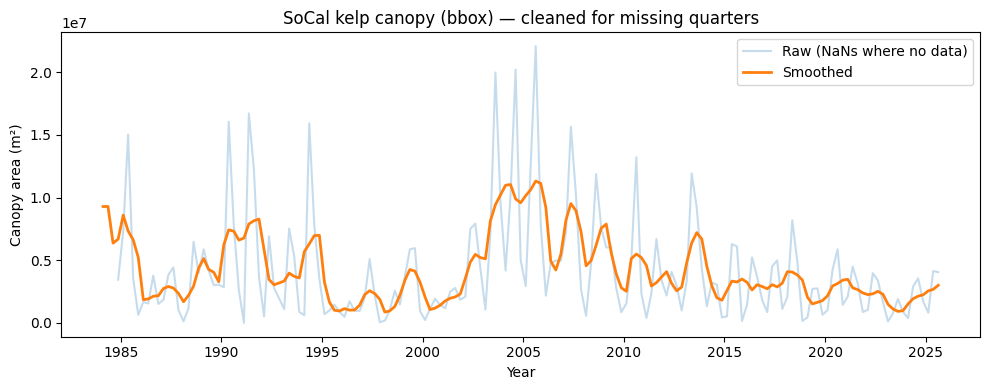

In [5]:
#5 load + clean kelp timeseries (from CSV) + plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_kelp = pd.read_csv("../data/kelp_timeseries_bbox.csv", index_col=0, parse_dates=True).sort_index()

# If coverage is 0, kelp_area=0 is "no data", not real zero kelp
df_kelp.loc[df_kelp["coverage"] == 0, "kelp_area"] = np.nan

# Recompute smooth after fixing missing data
df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()

print(df_kelp[["kelp_area","coverage","kelp_smooth"]].head(10))

plt.figure(figsize=(10,4))
plt.plot(df_kelp.index, df_kelp["kelp_area"], alpha=0.25, label="Raw (NaNs where no data)")
plt.plot(df_kelp.index, df_kelp["kelp_smooth"], linewidth=2, label="Smoothed")
plt.title("SoCal kelp canopy (bbox) — cleaned for missing quarters")
plt.xlabel("Year")
plt.ylabel("Canopy area (m²)")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
#6 “official analysis table” (kelp + SST)
import pandas as pd
import numpy as np

# 0) Ensure SST exists (load from disk if not in memory)
try:
    sst_quarterly
except NameError:
    sst_path = "../data/sst_quarterly_bbox.csv"
    sst_quarterly = pd.read_csv(sst_path, index_col=0, parse_dates=True).iloc[:, 0]
    sst_quarterly.name = "sst"
    print("Loaded SST quarterly from:", sst_path)

# 1) quarter-align kelp (IMPORTANT: coverage should be max, not mean)
df_kelp_q = df_kelp[["kelp_area","kelp_smooth","coverage"]].copy()
df_kelp_q["q"] = df_kelp_q.index.to_period("Q")

df_kelp_q = df_kelp_q.groupby("q").agg({
    "kelp_area": "mean",
    "kelp_smooth": "mean",
    "coverage": "max"
})

df_kelp_q.index = df_kelp_q.index.to_timestamp("Q")

# 2) quarter-align SST
sst_q = sst_quarterly.copy()
if isinstance(sst_q, pd.DataFrame):
    sst_q = sst_q.iloc[:, 0]

sst_q.index = pd.to_datetime(sst_q.index)
sst_q = sst_q.groupby(sst_q.index.to_period("Q")).mean()
sst_q.index = sst_q.index.to_timestamp("Q")

df_sst = sst_q.to_frame("sst")
df_sst["sst_anom"] = df_sst["sst"] - df_sst.groupby(df_sst.index.quarter)["sst"].transform("mean")

# 3) merge
df_combo = df_kelp_q.join(df_sst, how="inner")

# Optional: drop quarters with low coverage (keeps only reliable observations)
cov_thresh = 0.8 * df_combo["coverage"].max()
df_combo = df_combo[df_combo["coverage"] >= cov_thresh]

print("df_combo rows:", len(df_combo))
print("range:", df_combo.index.min(), "to", df_combo.index.max())
print(df_combo.head())

out_csv = "../data/analysis_table_kelp_sst_bbox.csv"
df_combo.to_csv(out_csv)
print("Saved:", out_csv)


FileNotFoundError: [Errno 2] No such file or directory: '../data/sst_quarterly_bbox.csv'

In [ ]:
#7 save SST quarterly (one-time)
import pandas as pd

# Run this right after you build sst_quarterly the first time.
# Then the “official analysis table” cell can auto-load it later.

if isinstance(sst_quarterly, pd.DataFrame):
    sst_quarterly = sst_quarterly.iloc[:, 0]

sst_quarterly.index = pd.to_datetime(sst_quarterly.index)
sst_quarterly.name = "sst"

sst_out = "../data/sst_quarterly_bbox.csv"
sst_quarterly.to_csv(sst_out)
print("Saved:", sst_out, "| rows:", len(sst_quarterly), "| range:", sst_quarterly.index.min(), "to", sst_quarterly.index.max())
